In [1]:
import sys
sys.path.append("../src")

In [2]:
from integrator import ComplexIntegrator
from context_manager import TriangleIntegrandEvaluator,TriangleIntegrandContext, spherical
import oneloop_bridge
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from integrand_builder import IntegrandBuilder
from wrapped_eval import WrappedEvaluator

# do this to trigger the banner here so it doesn't get in the way later
oneloop_bridge.set_renormalization_scale(1.0)

import symbolica as sb

rng = sb.RandomNumberGenerator(1, 0)

########################################################################
#                                                                      #
#                        You are using OneLOop                         #
#                                                                      #
# for the evaluation of 1-loop scalar 1-, 2-, 3- and 4-point functions #
#                                                                      #
# author: Andreas van Hameren <hamerenREMOVETHIS@ifj.edu.pl>           #
#   date: 2024-11-23                                                   #
#                                                                      #
# Please cite                                                          #
#    A. van Hameren,                                                   #
#      Comput.Phys.Commun. 182 (2011) 2427-2438, arXiv:1007.4716       #
#    A. van Hameren, C.G. Papadopoulos and R. Pittau,                  #
#      JHEP 0909:106,2009, arXiv:0903.4665         

In [3]:
ctx = TriangleIntegrandContext()
ib = IntegrandBuilder()
one_div_unsub = TriangleIntegrandEvaluator(context = ctx, evaluator = WrappedEvaluator(sb.N(1)/ib.unsubtracted(), ib.get_args(), "one_div_unsubtracted", True))

full_integrand = TriangleIntegrandEvaluator(context = ctx, evaluator = WrappedEvaluator(ib.combined_result(), ib.get_args(), "combined_result", True))

Compiling evaluator: "one_div_unsubtracted"
Done!
Compiling evaluator: "combined_result"
Done!


In [4]:
reference_values = []
p2s_ref = np.linspace(170,220, 225)
for p2 in p2s_ref:
    ctx.set_anomalous_configuration(p2 = p2)
    reference_values.append(ctx.get_reference())

integral_values = []
p2s = np.linspace(175,215, 20)
for p2 in tqdm(p2s):
    ctx.set_anomalous_configuration(p2 = p2)
    ci = ComplexIntegrator(3)
    res = ci.integrate(full_integrand.eval, spherical, 50, 100, rng)
    integral_values.append(res)
    
integral_values = np.array(integral_values)
reference_values = np.array(reference_values)

100%|██████████| 20/20 [00:15<00:00,  1.31it/s]


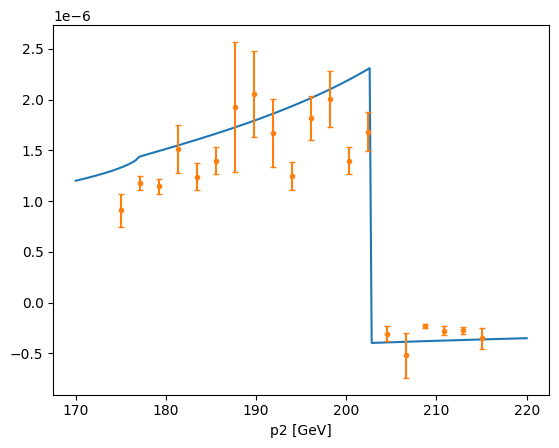

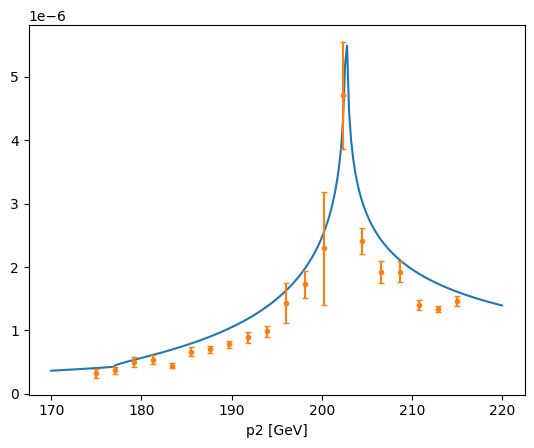

In [5]:
plt.plot(p2s_ref, reference_values.real)

r_avg = np.array([v.real_avg for v in integral_values])
r_err = np.array([v.real_err for v in integral_values])

im_avg = np.array([v.imag_avg for v in integral_values])
im_err = np.array([v.imag_err for v in integral_values])

plt.errorbar(p2s, r_avg,r_err, fmt='.', ls = '', capsize=2)
plt.xlabel("p2 [GeV]")
plt.show()

plt.plot(p2s_ref, reference_values.imag)
plt.errorbar(p2s, im_avg,im_err, fmt='.', ls = '', capsize=2)
plt.xlabel("p2 [GeV]")
plt.show()

In [6]:
regularization = 1e-2
reference_values = []
p2s_ref = np.linspace(170,220, 225)
for p2 in p2s_ref:
    ctx.set_anomalous_configuration(p2 = p2)
    ctx.masses = [m-1j*regularization for m in ctx.masses]
    reference_values.append(ctx.get_reference())

integral_values = []
p2s = np.linspace(175,215, 20)
for p2 in tqdm(p2s):
    ctx.set_anomalous_configuration(p2 = p2)
    ctx.masses = [m-1j*regularization for m in ctx.masses]
    ci = ComplexIntegrator(3)
    res = ci.integrate(full_integrand.eval, spherical, 50, 100, rng)
    integral_values.append(res)
    
integral_values = np.array(integral_values)
reference_values = np.array(reference_values)

100%|██████████| 20/20 [00:11<00:00,  1.74it/s]


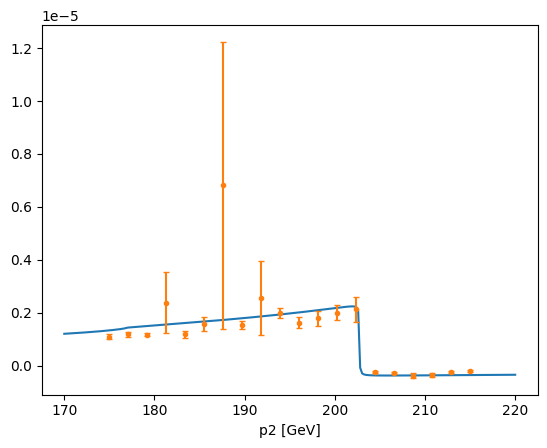

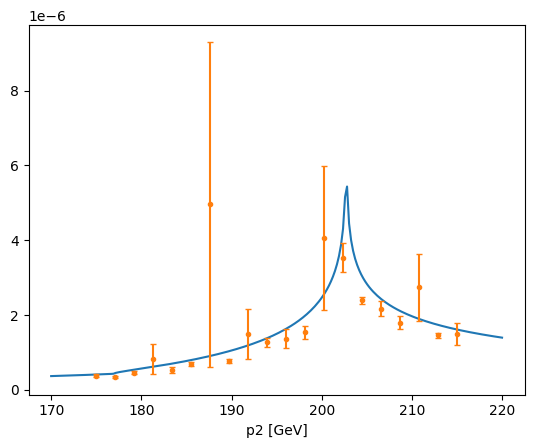

In [7]:
plt.plot(p2s_ref, reference_values.real)

r_avg = np.array([v.real_avg for v in integral_values])
r_err = np.array([v.real_err for v in integral_values])

im_avg = np.array([v.imag_avg for v in integral_values])
im_err = np.array([v.imag_err for v in integral_values])

plt.errorbar(p2s, r_avg,r_err, fmt='.', ls = '', capsize=2)
plt.xlabel("p2 [GeV]")
plt.show()

plt.plot(p2s_ref, reference_values.imag)
plt.errorbar(p2s, im_avg,im_err, fmt='.', ls = '', capsize=2)
plt.xlabel("p2 [GeV]")
plt.show()

In [9]:
ctx.set_anomalous_configuration(p2 = 202)
plotter = one_div_unsub.plot_contour((-20,20), (-20,20), (-20,20), 100)
plotter.show_grid()
plotter.show()

Widget(value='<iframe src="http://localhost:38035/index.html?ui=P_0x7537509f30e0_0&reconnect=auto" class="pyvi…

In [12]:
ctx.set_anomalous_configuration(p2 = 203.5)
plotter = one_div_unsub.plot_contour((-20,20), (-20,20), (-20,20), 100)
plotter.show_grid()
plotter.show()

Widget(value='<iframe src="http://localhost:38035/index.html?ui=P_0x75372a1c0740_3&reconnect=auto" class="pyvi…